In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report ,confusion_matrix 
from sklearn.tree import DecisionTreeClassifier , plot_tree

In [3]:
df = pd.read_csv('shop_smart_ecommerce.csv')

In [4]:
df.shape
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
X = df.drop("Revenue" , axis=1)
y = df["Revenue"]

In [8]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

In [17]:
X_train , X_test , y_train , y_test = train_test_split(
    X, y , test_size = 0.2 , random_state=42)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [19]:
model = DecisionTreeClassifier(
    max_depth=6,              
    min_samples_leaf=30,     
    class_weight="balanced",  
    random_state=42
)

In [20]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ]
)

In [21]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=30,
                                        random_state=42))])

In [24]:
y_pred = pipe.predict(X_test)

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6356011183597391

Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.84      0.90      2055
        True       0.52      0.83      0.64       411

    accuracy                           0.84      2466
   macro avg       0.74      0.84      0.77      2466
weighted avg       0.89      0.84      0.85      2466


Confusion Matrix:
 [[1734  321]
 [  70  341]]


[Text(0.5, 0.8333333333333334, 'x[8] <= -0.313\ngini = 0.5\nsamples = 9864\nvalue = [4932.0, 4932.0]'),
 Text(0.25, 0.5, 'x[21] <= 0.5\ngini = 0.294\nsamples = 7703\nvalue = [4369.657, 955.431]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'x[6] <= -0.454\ngini = 0.217\nsamples = 2161\nvalue = [562.343, 3976.569]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

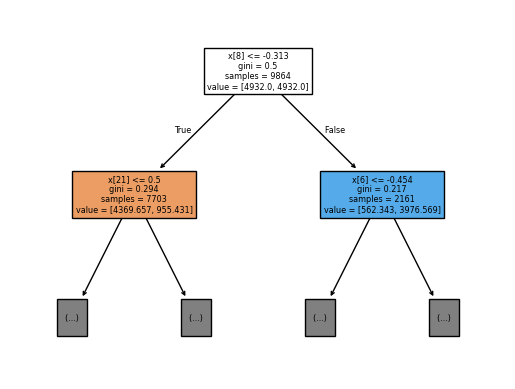

In [32]:
plot_tree(
    model,
    filled = True,
    max_depth = 1
)

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [20, 30, 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best F1: 0.6295841821702071
Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 50}


In [33]:
model2 = DecisionTreeClassifier(
    max_depth=4,              
    min_samples_leaf=50,     
    class_weight="balanced",  
    random_state=42
)
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", model2)
    ]
)
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6341030195381883

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.83      0.89      2055
        True       0.50      0.87      0.63       411

    accuracy                           0.83      2466
   macro avg       0.73      0.85      0.76      2466
weighted avg       0.89      0.83      0.85      2466


Confusion Matrix:
 [[1697  358]
 [  54  357]]
